# MZI Delay Arm -- Dense delta_L_um Sweep (Library Densification)

This notebook densifies `03_mzi_arm.ipynb`'s own `delta_L_um` sweep at two
`radius_um` values, for use by `pic_toolkit.optimization.arm_library`'s
length-axis S-parameter interpolation (needed for the MUX2 stage-1/stage-2
adjoint optimization -- see `docs/simulation_settings_record.md`'s
"`circuits/` MUX2 (N=4 lattice) geometry-optimization program" section; that
optimization effort is now paused). It does **not** modify `03_mzi_arm.ipynb`
itself -- both stages below reuse that notebook's already-validated geometry
and sweep tolerances, adding new points only:

- **Stage 1** (`radius_um=5.0`): the stage-1 MUX lattice's own arm, extending
  `03_mzi_arm.ipynb`'s existing `{14.0, 15.0, 17.5, 20.0, 25.0, 30.0}` sweep to
  an even 2um grid from the geometry's feasible floor (~13.27um) up to 34um.
- **Stage 2** (`radius_um=2.5`): the MUX4 tree's stage2_up/stage2_down arm
  (`circuits/wdm_mux4_sax.ipynb`'s own bend radius), densifying the existing
  `delta_L_um=7.5` fixed point across a generous window for gradient-based
  search -- kept to this one clean, round reference value rather than also
  including `wdm_mux4_sax.ipynb`'s own production-optimization-derived
  calibration point, which belongs to that specific design exercise, not to
  this notebook's own general parameter-behavior exploration.

Each stage saves to its own new sibling directory under
`data/sparams/mzi_arm/`, so the original `sweep/`/`sweep_r2.5/` directories'
provenance stays untouched (points already covered there are not
re-simulated).

**Do not use "Run All."** Each point is a full 2-direction FDTD simulation at
resolution=40; on this machine's limited RAM, run cells one at a time and
expect the full sweep (17 new points total) to take a long time (this repo's
own `CLAUDE.md` notes a full `simulate_baseline()` + sweep "can take
hours").

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from pic_toolkit.meep_sim import mzi_arm
from pic_toolkit import sparams, sweep, style

style.apply_style()
%matplotlib inline


## 1. Purpose

This notebook has no simulation of its own in this section -- see the
top markdown cell above for the full purpose statement. The two sections below
are independent and can be run in either order.

## 2. Stage 1 -- radius_um=5.0 dense grid

In [2]:
params = dict(mzi_arm.DEFAULT_PARAMS)  # same working copy convention as 03_mzi_arm.ipynb
params


{'wg_width_um': 0.5,
 'core_index': 2.7,
 'clad_index': 1.44,
 'polarization': 'TE',
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'resolution': 40,
 'dpml_um': 1.0,
 'radius_um': 5.0,
 'bend_type': 'euler',
 'extra_straight_um': 0.864,
 'lead_len_um': 3.0,
 'n_freq': 21,
 'margin_um': 1.5,
 'port_offset_um': 1.0,
 'source_offset_um': 0.5}

### 2.1 New target grid

`extra_straight_um_for_delta_L` converts each target `delta_L_um` to this
geometry's own swept parameter (`extra_straight_um`), raising `ValueError` if
a target is below the floor (~13.27um at `radius_um=5.0`, `bend_type="euler"`)
-- none of these targets are.

In [3]:
EXISTING_DELTA_L_UM = [14.0, 15.0, 17.5, 20.0, 25.0, 30.0]  # already in data/sparams/mzi_arm/sweep/
NEW_DELTA_L_UM = [16.0, 18.0, 22.0, 24.0, 26.0, 28.0, 32.0, 34.0]  # this notebook's own new points

NEW_EXTRA_STRAIGHT_UM = [mzi_arm.extra_straight_um_for_delta_L(dl, params) for dl in NEW_DELTA_L_UM]
print(list(zip(NEW_DELTA_L_UM, [round(e, 4) for e in NEW_EXTRA_STRAIGHT_UM])))


[(16.0, 1.364), (18.0, 2.364), (22.0, 4.364), (24.0, 5.364), (26.0, 6.364), (28.0, 7.364), (32.0, 9.364), (34.0, 10.364)]


### 2.2 Run the sweep

Same loose sweep tolerances `03_mzi_arm.ipynb` uses (this is the same
geometry family, just denser sampling) -- `sweep.grid_sweep` saves one
artifact per point as it completes, so an interrupted run loses no
already-finished points.

> **STOP -- this cell runs real FDTD simulations (8 points, each a
> 2-direction resolution=40 run). Expect a long runtime. Run it, then
> wait.**

In [4]:
SWEEP_CHECK_KWARGS = dict(energy_tol=0.15, reciprocity_tol=0.15, passivity_tol=0.05, max_loss_fraction=0.30)

sweep_rows_stage1 = sweep.grid_sweep(
    simulate_fn=mzi_arm.simulate_baseline,
    base_params=params,
    param_grid={"extra_straight_um": NEW_EXTRA_STRAIGHT_UM},
    artifact_dir=Path("../data/sparams/mzi_arm/sweep_dense2um"),
    component_name="mzi_arm",
    check_kwargs=SWEEP_CHECK_KWARGS,
)
n_passed = sum(row["validation_passed"] for row in sweep_rows_stage1)
print(f"stage-1 dense delta_L sweep: {n_passed}/{len(sweep_rows_stage1)} points within the (loose) sweep tolerance")
sweep.save_manifest(sweep_rows_stage1, Path("../data/sparams/mzi_arm/sweep_dense2um/manifest.csv"))


stage-1 dense delta_L sweep: 8/8 points within the (loose) sweep tolerance


### 2.3 Visualize: transmission and loss across the combined (existing + new) grid

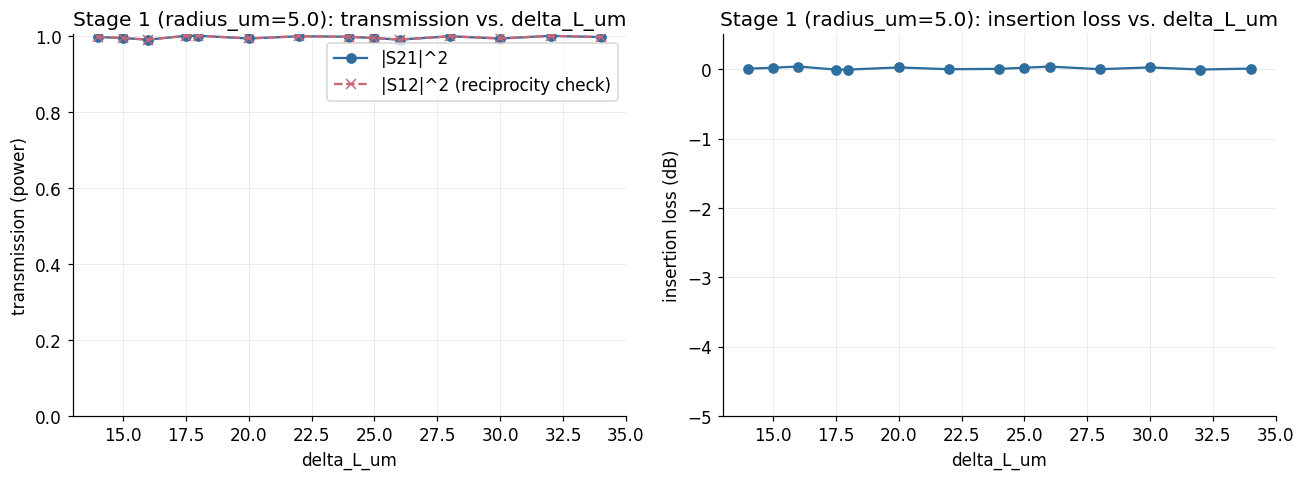

In [5]:
ALL_DELTA_L_UM_STAGE1 = sorted(EXISTING_DELTA_L_UM + NEW_DELTA_L_UM)

def _artifact_dir_and_extra_stage1(delta_L_um):
    if delta_L_um in EXISTING_DELTA_L_UM:
        return Path("../data/sparams/mzi_arm/sweep"), mzi_arm.extra_straight_um_for_delta_L(delta_L_um, params)
    return Path("../data/sparams/mzi_arm/sweep_dense2um"), mzi_arm.extra_straight_um_for_delta_L(delta_L_um, params)

delta_L_achieved, s21_center, s12_center, loss_db_center = [], [], [], []
for dl_target in ALL_DELTA_L_UM_STAGE1:
    art_dir, extra = _artifact_dir_and_extra_stage1(dl_target)
    tag = f"extra_straight{extra}"
    a = sparams.load_artifact(art_dir / f"mzi_arm_{tag}")
    mid = len(a.wavelengths_um) // 2
    s21, s12 = a.s_matrix["21"][mid], a.s_matrix["12"][mid]
    delta_L_achieved.append(mzi_arm.delta_L_um_from_extra(extra, params))
    s21_center.append(np.abs(s21) ** 2)
    s12_center.append(np.abs(s12) ** 2)
    loss_db_center.append(-10 * np.log10(np.abs(s21) ** 2))

delta_L_achieved = np.array(delta_L_achieved)

fig, (ax_t, ax_l) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_t.plot(delta_L_achieved, s21_center, "o-", color=style.COLOR_STEEL, label="|S21|^2")
ax_t.plot(delta_L_achieved, s12_center, "x--", color=style.COLOR_ROSE, label="|S12|^2 (reciprocity check)")
ax_t.set_xlabel("delta_L_um"); ax_t.set_ylabel("transmission (power)")
ax_t.set_title("Stage 1 (radius_um=5.0): transmission vs. delta_L_um")
ax_t.set_ylim(0, 1.005); ax_t.legend()

ax_l.plot(delta_L_achieved, loss_db_center, "o-", color=style.COLOR_STEEL)
ax_l.set_xlabel("delta_L_um"); ax_l.set_ylabel("insertion loss (dB)")
ax_l.set_title("Stage 1 (radius_um=5.0): insertion loss vs. delta_L_um")
ax_l.set_ylim(-5, 0.5)
fig.tight_layout()
plt.show()


## 3. Stage 2 -- radius_um=2.5 dense grid

This stage builds a NEW arm-length FDTD library at `radius_um=2.5` (the bend
radius the MUX4 tree's stage2_up/stage2_down branches use, per
`circuits/wdm_mux4_sax.ipynb` -- distinct from stage 1's `radius_um=5.0`), for
use by `pic_toolkit.optimization.arm_library.load_arm_length_library(radius_um=2.5)`'s
length-axis S-parameter interpolation in the stage-2 adjoint optimization.

Only 1 point at this radius is reused here (`delta_L_um=7.5`, saved to
`data/sparams/mzi_arm/sweep_r2.5/` by `wdm_mux4_sax.ipynb`) -- far too sparse
for gradient-based search on its own. `wdm_mux4_sax.ipynb` also saved a
second point there, its own production-optimization-calibrated `delta_L_um`
(a value derived specifically for that circuit's own channel-routing design,
not a general point of interest for exploring this arm's own parameter
behavior) -- deliberately left out of this notebook's grid.

In [6]:
params = dict(mzi_arm.DEFAULT_PARAMS)
params["radius_um"] = 2.5  # stage-2 geometry -- DEFAULT_PARAMS's own radius_um=5.0 is stage-1's
params


{'wg_width_um': 0.5,
 'core_index': 2.7,
 'clad_index': 1.44,
 'polarization': 'TE',
 'wl_min_um': 1.3,
 'wl_max_um': 1.4,
 'resolution': 40,
 'dpml_um': 1.0,
 'radius_um': 2.5,
 'bend_type': 'euler',
 'extra_straight_um': 0.864,
 'lead_len_um': 3.0,
 'n_freq': 21,
 'margin_um': 1.5,
 'port_offset_um': 1.0,
 'source_offset_um': 0.5}

### 3.1 New target grid

Floor at `radius_um=2.5` (`bend_type="euler"`) is ~6.632um -- all targets
below are safely above it. Spans the existing 7.5/7.64um points (kept, not
re-simulated) up through 20um, giving the stage-2 Adam optimizer generous
search room.

In [7]:
EXISTING_DELTA_L_UM = [7.5]  # already in data/sparams/mzi_arm/sweep_r2.5/ -- the OTHER point saved
# there (wdm_mux4_sax.ipynb's own production-calibrated delta_L_um) is deliberately excluded, not
# a general-interest parameter value for this notebook's own exploration -- see markdown above.
NEW_DELTA_L_UM = [7.0, 8.0, 9.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0]

NEW_EXTRA_STRAIGHT_UM = [mzi_arm.extra_straight_um_for_delta_L(dl, params) for dl in NEW_DELTA_L_UM]
print(list(zip(NEW_DELTA_L_UM, [round(e, 4) for e in NEW_EXTRA_STRAIGHT_UM])))


[(7.0, 0.184), (8.0, 0.684), (9.0, 1.184), (10.0, 1.684), (12.0, 2.684), (14.0, 3.684), (16.0, 4.684), (18.0, 5.684), (20.0, 6.684)]


### 3.2 Run the sweep

Same loose sweep tolerances as the radius=5.0 sweep -- same geometry family,
just a different radius/denser sampling.

> **STOP -- this cell runs real FDTD simulations (9 points, each a
> 2-direction run). Expect a long runtime. Run it, then wait.**

In [8]:
SWEEP_CHECK_KWARGS = dict(energy_tol=0.15, reciprocity_tol=0.15, passivity_tol=0.05, max_loss_fraction=0.30)

sweep_rows_stage2 = sweep.grid_sweep(
    simulate_fn=mzi_arm.simulate_baseline,
    base_params=params,
    param_grid={"extra_straight_um": NEW_EXTRA_STRAIGHT_UM},
    artifact_dir=Path("../data/sparams/mzi_arm/sweep_r2p5_dense"),
    component_name="mzi_arm",
    check_kwargs=SWEEP_CHECK_KWARGS,
)
n_passed = sum(row["validation_passed"] for row in sweep_rows_stage2)
print(f"stage-2 (radius=2.5) dense delta_L sweep: {n_passed}/{len(sweep_rows_stage2)} points within the (loose) sweep tolerance")
sweep.save_manifest(sweep_rows_stage2, Path("../data/sparams/mzi_arm/sweep_r2p5_dense/manifest.csv"))


stage-2 dense delta_L sweep: 9/9 points within the (loose) sweep tolerance


### 3.3 Visualize: transmission and loss across the combined (existing + new) grid

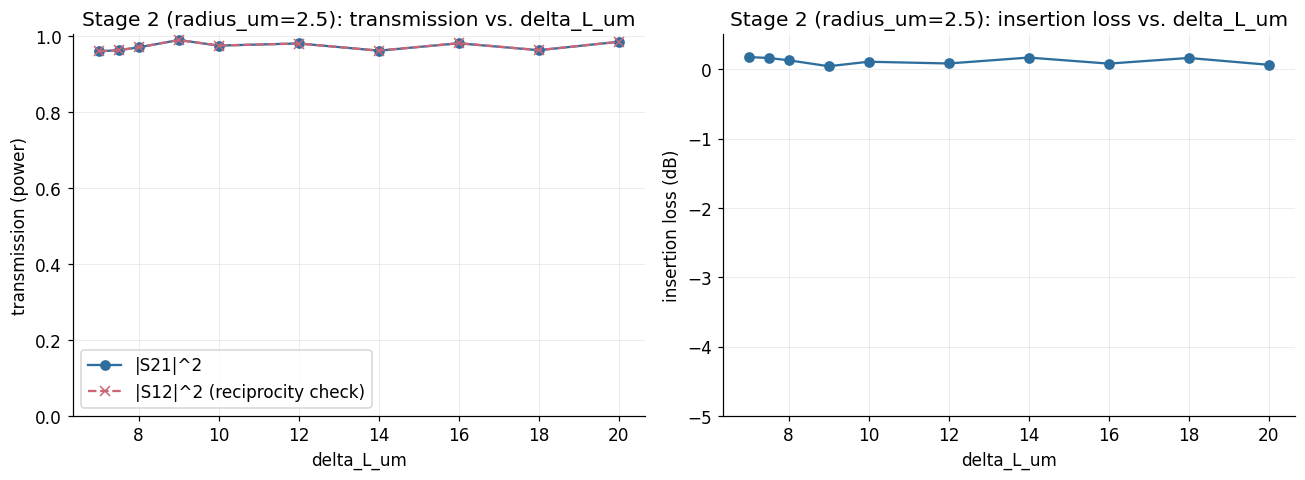

In [9]:
ALL_DELTA_L_UM_STAGE2 = sorted(EXISTING_DELTA_L_UM + NEW_DELTA_L_UM)

def _artifact_dir_and_extra_stage2(delta_L_um):
    if delta_L_um in EXISTING_DELTA_L_UM:
        return Path("../data/sparams/mzi_arm/sweep_r2.5"), mzi_arm.extra_straight_um_for_delta_L(delta_L_um, params)
    return Path("../data/sparams/mzi_arm/sweep_r2p5_dense"), mzi_arm.extra_straight_um_for_delta_L(delta_L_um, params)

delta_L_achieved, s21_center, s12_center, loss_db_center = [], [], [], []
for dl_target in ALL_DELTA_L_UM_STAGE2:
    art_dir, extra = _artifact_dir_and_extra_stage2(dl_target)
    tag = f"extra_straight{extra}"
    a = sparams.load_artifact(art_dir / f"mzi_arm_{tag}")
    mid = len(a.wavelengths_um) // 2
    s21, s12 = a.s_matrix["21"][mid], a.s_matrix["12"][mid]
    delta_L_achieved.append(mzi_arm.delta_L_um_from_extra(extra, params))
    s21_center.append(np.abs(s21) ** 2)
    s12_center.append(np.abs(s12) ** 2)
    loss_db_center.append(-10 * np.log10(np.abs(s21) ** 2))

delta_L_achieved = np.array(delta_L_achieved)

fig, (ax_t, ax_l) = plt.subplots(1, 2, figsize=(12, 4.5))
ax_t.plot(delta_L_achieved, s21_center, "o-", color=style.COLOR_STEEL, label="|S21|^2")
ax_t.plot(delta_L_achieved, s12_center, "x--", color=style.COLOR_ROSE, label="|S12|^2 (reciprocity check)")
ax_t.set_xlabel("delta_L_um"); ax_t.set_ylabel("transmission (power)")
ax_t.set_title("Stage 2 (radius_um=2.5): transmission vs. delta_L_um")
ax_t.set_ylim(0, 1.005); ax_t.legend()

ax_l.plot(delta_L_achieved, loss_db_center, "o-", color=style.COLOR_STEEL)
ax_l.set_xlabel("delta_L_um"); ax_l.set_ylabel("insertion loss (dB)")
ax_l.set_title("Stage 2 (radius_um=2.5): insertion loss vs. delta_L_um")
ax_l.set_ylim(-5, 0.5)
fig.tight_layout()
plt.show()


## 4. Summary

Both stages' dense grids are saved to `data/sparams/mzi_arm/sweep_dense2um/`
(radius_um=5.0) and `data/sparams/mzi_arm/sweep_r2p5_dense/` (radius_um=2.5),
alongside the original `sweep/`/`sweep_r2.5/` directories `03_mzi_arm.ipynb`
and `wdm_mux4_sax.ipynb` already produced. Together these give
`pic_toolkit.optimization.arm_library` a dense length-axis S-parameter
library at both bend radii for gradient-based adjoint optimization.